# Importing and exploring the data

 flight_id  booked  no_shows  bumped  total_compensation  compensation_per_bumped
         1     255        12       0                   0                        0
         2     255        17       0                   0                        0
         3     255        12       0                   0                        0
         4     255        17       0                   0                        0
         5     255        17       0                   0                        0


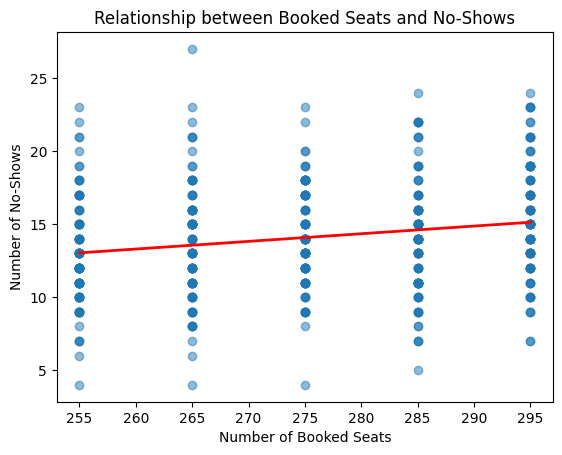

Regression coefficients of no_shows on booked: beta0 = -0.32, beta1 = 0.05
Standard deviation of no_shows: sigma = 3.77


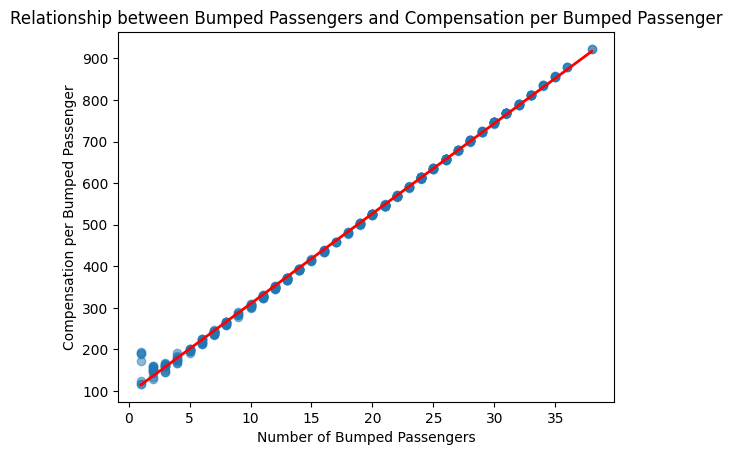

Regression coefficients of compensation_per_bumped on bumped: beta0 = 92.87, beta1 = 21.70
Standard deviation of compensation_per_bumped: sigma = 9.18


In [508]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# assign variables
available_seats = 250
revenue_per_seat = 600
N = 10000  # number of simulations


# load the data (.csv)
data = pd.read_csv('overbooking_data.csv')

# display the first few rows of the data without index
print(data.head().to_string(index=False))



# graph the relationship between booked and no_shows
plt.scatter(data['booked'], data['no_shows'], alpha=0.5)
plt.xlabel('Number of Booked Seats')
plt.ylabel('Number of No-Shows')
plt.title('Relationship between Booked Seats and No-Shows')
# add a red regression line
beta1, beta0 = np.polyfit(data['booked'], data['no_shows'], 1)
x = np.array([data['booked'].min(), data['booked'].max()])
y = beta0 + beta1 * x
plt.plot(x, y, color='red', linewidth=2)
plt.show()
# regression analysis: y(no_shows) = beta0 + beta1 * x(booked) + error, using numpy's polyfit function
x = data['booked']
y = data['no_shows']
beta1_ns, beta0_ns = np.polyfit(x, y, 1)
print(f"Regression coefficients of no_shows on booked: beta0 = {beta0_ns:.2f}, beta1 = {beta1_ns:.2f}")
# calculate the standard deviation of no_shows using numpy's std function
sigma_ns = np.std(data['no_shows'])
print(f"Standard deviation of no_shows: sigma = {sigma_ns:.2f}")



# remove the rows where bumped is 0 for a more accurate regression analysis of compensation_per_bumped on bumped, since compensation_per_bumped is only relevant for bumped passengers
bumped_not_0 = data[data['bumped'] > 0]
# graph the relationship between bumped and compensation_per_bumped
plt.scatter(bumped_not_0['bumped'], bumped_not_0['compensation_per_bumped'], alpha=0.5)
plt.xlabel('Number of Bumped Passengers')
plt.ylabel('Compensation per Bumped Passenger')
plt.title('Relationship between Bumped Passengers and Compensation per Bumped Passenger')
# add a red regression line
beta1_cb, beta0_cb = np.polyfit(bumped_not_0['bumped'], bumped_not_0['compensation_per_bumped'], 1)
x = np.array([bumped_not_0['bumped'].min(), bumped_not_0['bumped'].max()])
y = beta0_cb + beta1_cb * x
plt.plot(x, y, color='red', linewidth=2)
plt.show()
# regression analysis: y(compensation_per_bumped) = beta0_cb + beta1_cb * x(bumped) + error, using numpy's polyfit function
x = bumped_not_0['bumped']
y = bumped_not_0['compensation_per_bumped']
beta1_cb, beta0_cb = np.polyfit(x, y, 1)
print(f"Regression coefficients of compensation_per_bumped on bumped: beta0 = {beta0_cb:.2f}, beta1 = {beta1_cb:.2f}")
# find std from the regressed line and the actual data points, using numpy's std function
y_pred = beta0_cb + beta1_cb * x
sigma_cb = np.std(y - y_pred)
print(f"Standard deviation of compensation_per_bumped: sigma = {sigma_cb:.2f}")

# Creating simulations

Optimal number of bookings: 266
Expected profit at optimal: $148,992.46


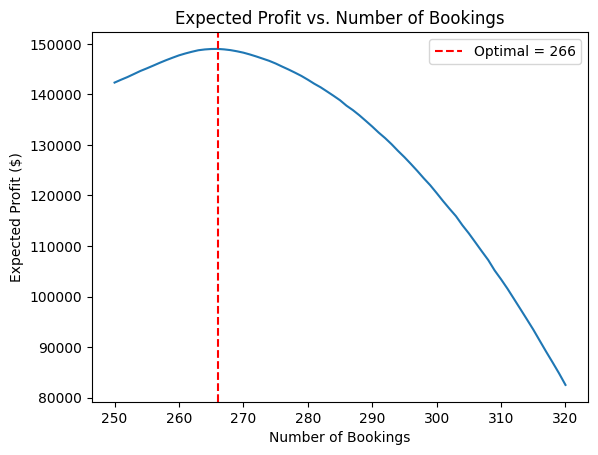

In [509]:
# function to simulate no_shows based on the regression coefficients and standard deviation
def no_shows(booked, beta0, beta1, sigma, N):
    mean_no_shows = beta0 + beta1 * booked
    simulated_no_shows = np.random.normal(mean_no_shows, sigma, N)
    return simulated_no_shows

def compensation_per_bumped(bumped, beta0, beta1, sigma):
    mean_compensation = beta0 + beta1 * bumped
    simulated_compensation = np.random.normal(mean_compensation, sigma, len(bumped) if hasattr(bumped, '__len__') else 1)
    return simulated_compensation

# loop over candidate booking numbers to find the optimal
booking_range = range(250, 321)
expected_profits = []

for booked in booking_range:
    simulated_no_shows = no_shows(booked, beta0_ns, beta1_ns, sigma_ns, N)
    show_ups = booked - simulated_no_shows
    bumped = np.maximum(0, show_ups - available_seats)
    comp = compensation_per_bumped(bumped, beta0_cb, beta1_cb, sigma_cb)
    seated = np.minimum(show_ups, available_seats)
    profit = seated * revenue_per_seat - bumped * comp
    expected_profits.append(np.mean(profit))

optimal_booked = list(booking_range)[np.argmax(expected_profits)]
print(f"Optimal number of bookings: {optimal_booked}")
print(f"Expected profit at optimal: ${max(expected_profits):,.2f}")

# plot expected profit vs bookings
plt.plot(list(booking_range), expected_profits)
plt.xlabel('Number of Bookings')
plt.ylabel('Expected Profit ($)')
plt.title('Expected Profit vs. Number of Bookings')
plt.axvline(optimal_booked, color='red', linestyle='--', label=f'Optimal = {optimal_booked}')
plt.legend()
plt.show()
